#  Le Langage des Machines — Acte III
## Deviner la classe : Naive Bayes

**Auteur :** Glorie M. WOWO | Data Scientist / EdTech Entrepreneur

---

##  Objectif de cet acte

Dans l'Acte I, on a appris à **transformer un texte en vecteur** (Bag of Words).  
Dans l'Acte II, on a appris à **pondérer les mots importants** (TF-IDF).

**Maintenant, on veut UTILISER ces vecteurs pour répondre à une question :**

> Cet avis est-il **positif** ou **négatif** ?

C'est le rôle de **Naive Bayes** : un classifieur qui utilise les probabilités pour deviner la classe.

---

# PARTIE 1 : Le Récit

---

## 1.1 Le nouveau défi de Glorie

Glorie reçoit maintenant **des centaines d'avis** chaque semaine sur SUCCEED. Elle ne peut plus tous les lire.

Elle aimerait qu'un algorithme les trie automatiquement : **positif** ou **négatif** ?

Mais comment une machine peut-elle "comprendre" qu'un avis est positif ?

## 1.2 L'observation de Glorie

En parcourant ses avis, Glorie remarque un **pattern** :

- Les avis **positifs** contiennent souvent : *"génial"*, *"excellent"*, *"super"*
- Les avis **négatifs** contiennent souvent : *"difficile"*, *"confus"*, *"compliqué"*

**L'idée de Glorie** : et si on comptait les mots pour deviner la classe ?

In [72]:
# Glorie regarde ses 7 avis déjà classés
avis_positifs = [
    "Le cours est génial",          # contient "génial"
    "Formation super j'ai adoré",   # contient "super"
    "Excellent cours je recommande", # contient "excellent"
    "Le formateur est génial",       # contient "génial"
    "Super formation très claire"    # contient "super"
]

avis_negatifs = [
    "C'était difficile à suivre",    # contient "difficile"
    "Cours trop difficile et confus"  # contient "difficile", "confus"
]

print("=" * 50)
print("LES 7 AVIS DE Glorie")
print("=" * 50)
print(f"\n✅ POSITIFS ({len(avis_positifs)} avis) :")
for avis in avis_positifs:
    print(f"   • \"{avis}\"")

print(f"\n❌ NÉGATIFS ({len(avis_negatifs)} avis) :")
for avis in avis_negatifs:
    print(f"   • \"{avis}\"")

LES 7 AVIS DE SARAH

✅ POSITIFS (5 avis) :
   • "Le cours est génial"
   • "Formation super j'ai adoré"
   • "Excellent cours je recommande"
   • "Le formateur est génial"
   • "Super formation très claire"

❌ NÉGATIFS (2 avis) :
   • "C'était difficile à suivre"
   • "Cours trop difficile et confus"


In [73]:
# Glorie compte les mots clés dans chaque classe
def compter_mot(mot, liste_avis):
    return sum(mot.lower() in avis.lower() for avis in liste_avis)

mots_a_tester = ["génial", "super", "excellent", "difficile", "confus"]

print("COMPTAGE DES MOTS PAR CLASSE")
print("=" * 60)
print(f"{'Mot':<14} {'Positifs (5)':>14} {'Négatifs (2)':>14} {'Signal':>14}")
print("-" * 60)

for mot in mots_a_tester:
    n_pos = compter_mot(mot, avis_positifs)
    n_neg = compter_mot(mot, avis_negatifs)
    
    if n_pos > n_neg:
        signal = "→ POSITIF"
    elif n_neg > n_pos:
        signal = "→ NÉGATIF"
    else:
        signal = "→ neutre"
    
    print(f"  {mot:<12} {n_pos:>14} {n_neg:>14} {signal:>14}")

print("\n💡 Certains mots sont des INDICES forts de la classe !")

COMPTAGE DES MOTS PAR CLASSE
Mot              Positifs (5)   Négatifs (2)         Signal
------------------------------------------------------------
  génial                    2              0      → POSITIF
  super                     2              0      → POSITIF
  excellent                 1              0      → POSITIF
  difficile                 0              2      → NÉGATIF
  confus                    0              1      → NÉGATIF

💡 Certains mots sont des INDICES forts de la classe !


## 1.3 Des comptages aux probabilités

Glorie a compté les mots. Maintenant, transformons ces comptages en **probabilités** :

- Le mot **"génial"** apparaît dans **2 avis positifs sur 5** → P(génial | positif) = 2/5 = **0.40** (40%)
- Le mot **"génial"** apparaît dans **0 avis négatifs sur 2** → P(génial | négatif) = 0/2 = **0.00** (0%)

- Le mot **"difficile"** apparaît dans **0 avis positifs sur 5** → P(difficile | positif) = 0/5 = **0.00** (0%)
- Le mot **"difficile"** apparaît dans **2 avis négatifs sur 2** → P(difficile | négatif) = 2/2 = **1.00** (100%)

**Traduction** : Si un nouvel avis contient "génial", il a **40% de chances** de venir de la classe positive et **0% de chances** de venir de la classe négative.

Le choix est clair !

In [74]:
# Calculons les probabilités pour chaque mot
n_positifs = len(avis_positifs)   # 5
n_negatifs = len(avis_negatifs)   # 2

print("DES COMPTAGES AUX PROBABILITÉS")
print("=" * 70)
print(f"{'Mot':<14} {'P(mot|positif)':>16} {'P(mot|négatif)':>16} {'Signal':>16}")
print("-" * 70)

for mot in mots_a_tester:
    n_pos = compter_mot(mot, avis_positifs)
    n_neg = compter_mot(mot, avis_negatifs)
    
    p_pos = n_pos / n_positifs
    p_neg = n_neg / n_negatifs
    
    if p_pos > p_neg:
        signal = "→ POSITIF"
    elif p_neg > p_pos:
        signal = "→ NÉGATIF"
    else:
        signal = "→ neutre"
    
    print(f"  {mot:<12} {n_pos}/{n_positifs} = {p_pos:<10.0%} {n_neg}/{n_negatifs} = {p_neg:<10.0%} {signal:>10}")

print("\n💡 Les probabilités montrent clairement quels mots 'penchent' vers quelle classe.")

DES COMPTAGES AUX PROBABILITÉS
Mot              P(mot|positif)   P(mot|négatif)           Signal
----------------------------------------------------------------------
  génial       2/5 = 40%        0/2 = 0%          → POSITIF
  super        2/5 = 40%        0/2 = 0%          → POSITIF
  excellent    1/5 = 20%        0/2 = 0%          → POSITIF
  difficile    0/5 = 0%         2/2 = 100%        → NÉGATIF
  confus       0/5 = 0%         1/2 = 50%         → NÉGATIF

💡 Les probabilités montrent clairement quels mots 'penchent' vers quelle classe.


## 1.4 Testons : classer un nouvel avis

Nouvel avis : **"Ce cours est génial"**

Le raisonnement :

1. Le mot **"génial"** est dedans
2. P(génial | positif) = 2/5 = **0.40**
3. P(génial | négatif) = 0/2 = **0.00**
4. Score positif (0.40) > Score négatif (0.00)

**→ Prédiction : POSITIF !**

C'est exactement ce que fait Naive Bayes, mais pour **tous** les mots à la fois.

---

# PARTIE 2 : La Technique

---

## 2.1 La formule de Bayes

Le théorème de Bayes nous donne la formule :

$$P(classe | texte) \propto P(texte | classe) \times P(classe)$$

**Traduction de chaque terme** :

| Terme | Signification | Exemple concret |
|-------|---------------|-----------------|
| **P(classe \| texte)** | Probabilité que l'avis soit +/- sachant son contenu | "Ce cours est génial" → P(positif \| texte) = ? |
| **P(texte \| classe)** | À quel point ce texte ressemble aux textes de cette classe | "génial" apparaît-il souvent dans les positifs ? |
| **P(classe)** | Probabilité a priori de la classe | 5 positifs sur 7 → P(positif) = 5/7 = 71% |

Le symbole **∝** signifie "proportionnel à" : on compare les scores entre les classes, pas besoin de la probabilité exacte.

## 2.2 L'hypothèse "naïve" : l'indépendance

### C'est quoi "indépendant" ?

Dire que deux mots sont **indépendants**, c'est dire que la présence de l'un **n'influence pas** la présence de l'autre.

> *Par exemple : savoir qu'un avis contient "génial" ne nous dit rien sur le fait qu'il contienne aussi "cours". Les deux mots sont traités comme s'ils n'avaient aucun lien entre eux.*

### Pourquoi cette hypothèse ?

**Le problème** : Calculer P(texte | classe) directement est très compliqué, car il faudrait connaître la probabilité de chaque combinaison possible de mots.

**L'hypothèse naïve** : On suppose que chaque mot est **indépendant** des autres. Du coup on peut multiplier les probabilités individuelles :

$$P(texte | classe) = P(mot_1 | classe) \times P(mot_2 | classe) \times ... \times P(mot_n | classe)$$

### Exemple chiffré

Pour l'avis **"cours génial"** dans la classe **positive** :

$$P(\text{"cours génial"} | positif) = P(cours | positif) \times P(génial | positif)$$

- P(cours | positif) = 3/5 = **0.60** ("cours" apparaît dans 3 avis positifs sur 5)
- P(génial | positif) = 2/5 = **0.40**
- P("cours génial" | positif) = 0.60 × 0.40 = **0.24**

Pour la classe **négative** :
- P(cours | négatif) = 1/2 = **0.50**
- P(génial | négatif) = 0/2 = **0.00**
- P("cours génial" | négatif) = 0.50 × 0.00 = **0.00**

**Score positif (0.24) >> Score négatif (0.00)** → Prédiction : POSITIF !

### C'est faux, mais ça marche

En réalité, les mots ne sont **pas** indépendants. Par exemple, "pas" et "bon" sont liés : quand on écrit "pas", on écrit souvent "bon" juste après.

Mais malgré cette simplification, Naive Bayes donne d'excellents résultats en pratique !

In [75]:
# Vérifions l'exemple chiffré avec notre corpus
print("EXEMPLE CHIFFRÉ : classer \"cours génial\"")
print("=" * 55)

# Comptages
p_cours_pos = compter_mot("cours", avis_positifs) / n_positifs
p_genial_pos = compter_mot("génial", avis_positifs) / n_positifs

p_cours_neg = compter_mot("cours", avis_negatifs) / n_negatifs
p_genial_neg = compter_mot("génial", avis_negatifs) / n_negatifs

# Scores
score_pos = p_cours_pos * p_genial_pos
score_neg = p_cours_neg * p_genial_neg

print("\nClasse POSITIVE :")
print(f"  P(cours|+) = {compter_mot('cours', avis_positifs)}/{n_positifs} = {p_cours_pos:.2f}")
print(f"  P(génial|+) = {compter_mot('génial', avis_positifs)}/{n_positifs} = {p_genial_pos:.2f}")
print(f"  Score = {p_cours_pos:.2f} × {p_genial_pos:.2f} = {score_pos:.4f}")

print("\nClasse NÉGATIVE :")
print(f"  P(cours|-) = {compter_mot('cours', avis_negatifs)}/{n_negatifs} = {p_cours_neg:.2f}")
print(f"  P(génial|-) = {compter_mot('génial', avis_negatifs)}/{n_negatifs} = {p_genial_neg:.2f}")
print(f"  Score = {p_cours_neg:.2f} × {p_genial_neg:.2f} = {score_neg:.4f}")

print(f"\n🎯 Score positif ({score_pos:.4f}) > Score négatif ({score_neg:.4f})")
print(f"   → PRÉDICTION : POSITIF !")

EXEMPLE CHIFFRÉ : classer "cours génial"

Classe POSITIVE :
  P(cours|+) = 2/5 = 0.40
  P(génial|+) = 2/5 = 0.40
  Score = 0.40 × 0.40 = 0.1600

Classe NÉGATIVE :
  P(cours|-) = 1/2 = 0.50
  P(génial|-) = 0/2 = 0.00
  Score = 0.50 × 0.00 = 0.0000

🎯 Score positif (0.1600) > Score négatif (0.0000)
   → PRÉDICTION : POSITIF !


## 2.3 Le problème du zéro et le lissage de Laplace

Vous avez remarqué ? P(génial | négatif) = **0/2 = 0.00**

Et 0 × quoi que ce soit = **0**.

Ça veut dire qu'un seul mot absent d'une classe **détruit** toute la probabilité de cette classe, même si tous les autres mots pointent vers elle !

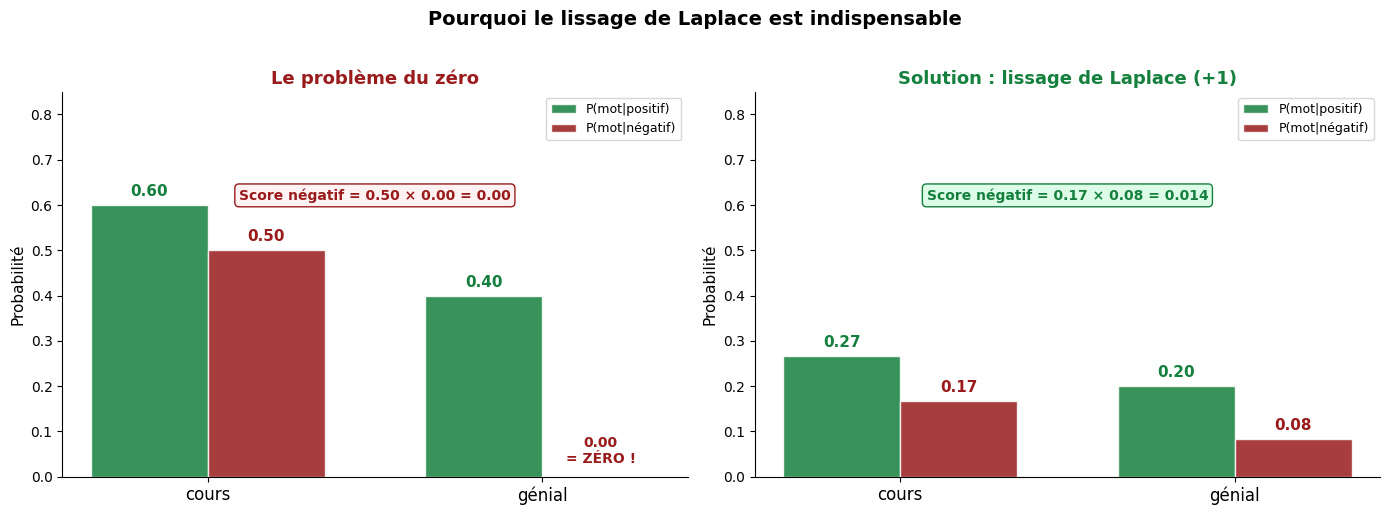

In [76]:
# Visualisation du problème du zéro
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Panneau 1 : Le problème ----
ax = axes[0]
mots = ["cours", "génial"]
proba_pos = [3/5, 2/5]
proba_neg = [1/2, 0/2]

x_pos = np.arange(len(mots))
width = 0.35

bars1 = ax.bar(x_pos - width/2, proba_pos, width, color='#15803d', alpha=0.85, label='P(mot|positif)', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, proba_neg, width, color='#991b1b', alpha=0.85, label='P(mot|négatif)', edgecolor='white')

# Annoter les barres
for bar, val in zip(bars1, proba_pos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color='#15803d')
for bar, val in zip(bars2, proba_neg):
    if val == 0:
        ax.text(bar.get_x() + bar.get_width()/2, 0.03, '0.00\n= ZÉRO !', ha='center', fontsize=10, fontweight='bold', color='#991b1b')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color='#991b1b')

ax.set_xticks(x_pos)
ax.set_xticklabels(mots, fontsize=12)
ax.set_ylabel('Probabilité', fontsize=11)
ax.set_title('Le problème du zéro', fontsize=13, fontweight='bold', color='#991b1b')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation : 0.50 × 0.00 = 0.00
ax.text(0.5, 0.72, 'Score négatif = 0.50 × 0.00 = 0.00', ha='center', fontsize=10, 
        color='#991b1b', fontweight='bold', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef2f2', edgecolor='#991b1b'))

# ---- Panneau 2 : La solution (Laplace) ----
ax = axes[1]

# Avec lissage de Laplace (alpha=1), vocabulaire simplifié V=10
V = 10
total_pos = 5 + V  # total mots + V
total_neg = 2 + V

proba_pos_lap = [(3+1)/total_pos, (2+1)/total_pos]
proba_neg_lap = [(1+1)/total_neg, (0+1)/total_neg]

bars1 = ax.bar(x_pos - width/2, proba_pos_lap, width, color='#15803d', alpha=0.85, label='P(mot|positif)', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, proba_neg_lap, width, color='#991b1b', alpha=0.85, label='P(mot|négatif)', edgecolor='white')

for bar, val in zip(bars1, proba_pos_lap):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color='#15803d')
for bar, val in zip(bars2, proba_neg_lap):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color='#991b1b')

ax.set_xticks(x_pos)
ax.set_xticklabels(mots, fontsize=12)
ax.set_ylabel('Probabilité', fontsize=11)
ax.set_title('Solution : lissage de Laplace (+1)', fontsize=13, fontweight='bold', color='#15803d')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation
score_neg_lap = proba_neg_lap[0] * proba_neg_lap[1]
ax.text(0.5, 0.72, f'Score négatif = {proba_neg_lap[0]:.2f} × {proba_neg_lap[1]:.2f} = {score_neg_lap:.3f}', ha='center', fontsize=10, 
        color='#15803d', fontweight='bold', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#dcfce7', edgecolor='#15803d'))

plt.suptitle('Pourquoi le lissage de Laplace est indispensable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### La formule du lissage de Laplace

Au lieu de calculer P(mot | classe) = comptage / total, on ajoute **+1** à chaque comptage :

$$P(mot | classe) = \frac{count(mot, classe) + 1}{total\_mots(classe) + |V|}$$

Où **|V|** = taille du vocabulaire (nombre de mots uniques).

**Exemple** : P(génial | négatif) avec lissage (V=10) :
- Sans lissage : 0/2 = **0.00** ← Problème !
- Avec lissage : (0+1)/(2+10) = 1/12 = **0.08** ← Petit mais pas zéro !

Ainsi, aucun mot n'a une probabilité de 0, et le calcul ne s'effondre jamais.

---

# PARTIE 3 : La Pratique avec Python

---

## 3.1 Le corpus SUCCEED

On crée un corpus réaliste et **déséquilibré** : SUCCEED est une plateforme bien notée, donc la majorité des avis sont positifs (75%).

In [77]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Corpus SUCCEED (déséquilibré : 75% positifs, car plateforme bien notée)
corpus = [
    # --- POSITIFS (15 avis) ---
    "Le cours de Python est génial j'ai adoré",
    "Formation excellente très pédagogue et claire",
    "Super cours j'ai beaucoup appris merci",
    "Le formateur est excellent très professionnel",
    "Cours génial je recommande vivement à tous",
    "Formation super bien expliquée et structurée",
    "J'ai adoré cette formation Python pratique",
    "Excellent contenu très pratique et concret",
    "Le cours est super bien organisé bravo",
    "Formation géniale merci beaucoup au formateur",
    "Très bonne formation je suis satisfait",
    "Cours clair et bien organisé parfait",
    "Parfait pour apprendre Python facilement",
    "Je recommande cette formation excellente",
    "Le meilleur cours que j'ai suivi",
    # --- NÉGATIFS (5 avis) ---
    "Le cours était trop difficile à suivre",
    # "Formation confuse et mal organisée décevant",
    "Je n'ai rien compris ",
    "Cours est compliqué ",
    "Un peu difficile à comprendre"
]

# Labels : 1 = Positif, 0 = Négatif
labels = [1]*15 + [0]*4

print("CORPUS SUCCEED")
print("=" * 45)
print(f"  Total : {len(corpus)} avis")
print(f"  ✅ Positifs : {sum(labels)} ({sum(labels)/len(labels):.0%})")
print(f"  ❌ Négatifs : {len(labels) - sum(labels)} ({(len(labels)-sum(labels))/len(labels):.0%})")
print(f"\n  💡 Le déséquilibre reflète la réalité :")
print(f"     SUCCEED est bien noté, donc plus d'avis positifs.")

CORPUS SUCCEED
  Total : 19 avis
  ✅ Positifs : 15 (79%)
  ❌ Négatifs : 4 (21%)

  💡 Le déséquilibre reflète la réalité :
     SUCCEED est bien noté, donc plus d'avis positifs.


## 3.2 Étape 1 : Transformer les textes en vecteurs

In [78]:
# ============================
# Option A : Bag of Words (CountVectorizer)
# ============================
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(corpus)

print("OPTION A : Bag of Words (CountVectorizer)")
print("=" * 50)
print(f"  Vocabulaire : {len(vectorizer_bow.get_feature_names_out())} mots")
print(f"  Matrice : {X_bow.shape[0]} docs × {X_bow.shape[1]} mots")
print(f"  Valeurs : comptages bruts (0, 1, 2...)")

# ============================
# Option B : TF-IDF (TfidfVectorizer)
# ============================
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(corpus)

print(f"\nOPTION B : TF-IDF (TfidfVectorizer)")
print("=" * 50)
print(f"  Vocabulaire : {len(vectorizer_tfidf.get_feature_names_out())} mots")
print(f"  Matrice : {X_tfidf.shape[0]} docs × {X_tfidf.shape[1]} mots")
print(f"  Valeurs : poids TF-IDF (entre 0 et 1)")

print(f"\n💡 Les deux options sont possibles !")
print(f"   BoW = comptages bruts, TF-IDF = poids pondérés")
print(f"   On va comparer les deux plus loin.")

OPTION A : Bag of Words (CountVectorizer)
  Vocabulaire : 57 mots
  Matrice : 19 docs × 57 mots
  Valeurs : comptages bruts (0, 1, 2...)

OPTION B : TF-IDF (TfidfVectorizer)
  Vocabulaire : 57 mots
  Matrice : 19 docs × 57 mots
  Valeurs : poids TF-IDF (entre 0 et 1)

💡 Les deux options sont possibles !
   BoW = comptages bruts, TF-IDF = poids pondérés
   On va comparer les deux plus loin.


## 3.3 Étape 2 : Entraîner le modèle Naive Bayes

In [99]:
y = np.array(labels)

# Séparer en train/test (avec BoW pour commencer)
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.25, random_state=42
)

# Créer et entraîner le modèle
# MultinomialNB = version de Naive Bayes adaptée aux comptages de mots
# alpha=1.0 → lissage de Laplace (par défaut)
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

print("ENTRAÎNEMENT")
print("=" * 45)
print(f"  Données d'entraînement : {X_train.shape[0]} avis")
print(f"  Données de test : {X_test.shape[0]} avis")
print(f"  Lissage de Laplace : alpha = {model.alpha}")
print(f"\n  ✅ Modèle entraîné !")

ENTRAÎNEMENT
  Données d'entraînement : 14 avis
  Données de test : 5 avis
  Lissage de Laplace : alpha = 1.0

  ✅ Modèle entraîné !


## 3.4 Étape 3 : Évaluer le modèle

In [100]:
# Prédictions sur le test
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("ÉVALUATION")
print("=" * 45)
print(f"\n  Accuracy : {accuracy:.1%}")
print("\n" + classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))

ÉVALUATION

  Accuracy : 60.0%

              precision    recall  f1-score   support

     Négatif       0.00      0.00      0.00         0
     Positif       1.00      0.60      0.75         5

    accuracy                           0.60         5
   macro avg       0.50      0.30      0.38         5
weighted avg       1.00      0.60      0.75         5



/home/ensai/Documents/dataviz-course/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ensai/Documents/dataviz-course/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ensai/Documents/dataviz-course/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

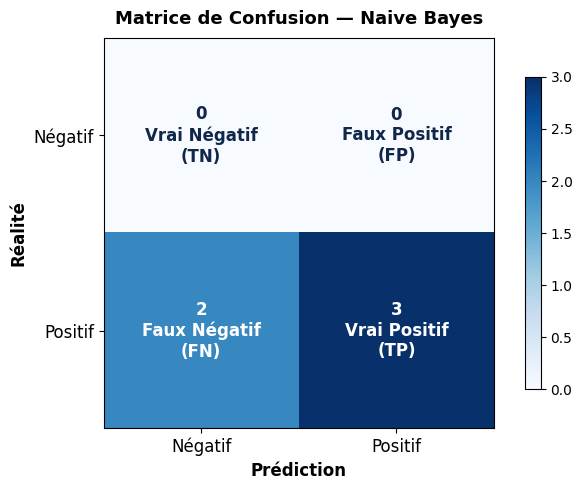

In [101]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')

classes = ['Négatif', 'Positif']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel('Prédiction', fontsize=12, fontweight='bold')
ax.set_ylabel('Réalité', fontsize=12, fontweight='bold')

# Labels dans les cellules
labels_cm = [['Vrai Négatif\n(TN)', 'Faux Positif\n(FP)'],
             ['Faux Négatif\n(FN)', 'Vrai Positif\n(TP)']]

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max()/2 else '#10274a'
        ax.text(j, i, f'{cm[i, j]}\n{labels_cm[i][j]}', ha='center', va='center', 
                fontsize=12, fontweight='bold', color=color)

ax.set_title('Matrice de Confusion — Naive Bayes', fontsize=13, fontweight='bold', pad=10)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## 3.5 Tester sur de nouveaux avis

In [102]:
# Nouveaux avis à classifier
nouveaux_avis = [
    "Ce cours est vraiment génial",
    # "Formation difficile et confuse",
    "Le formateur explique très bien",
    "Je n'ai pas aimé ce cours",
    "Excellente formation je recommande"
]

# Transformer et prédire
X_new = vectorizer_bow.transform(nouveaux_avis)
predictions = model.predict(X_new)
probas = model.predict_proba(X_new)

print("PRÉDICTIONS SUR NOUVEAUX AVIS")
print("=" * 65)
for avis, pred, proba in zip(nouveaux_avis, predictions, probas):
    classe = "POSITIF" if pred == 1 else "NÉGATIF"
    confiance = max(proba) * 100
    emoji = "✅" if pred == 1 else "❌"
    
    print(f"\n\"{avis}\"")
    print(f"  → {emoji} {classe} (confiance : {confiance:.0f}%)")
    print(f"     P(négatif) = {proba[0]:.1%} | P(positif) = {proba[1]:.1%}")

PRÉDICTIONS SUR NOUVEAUX AVIS

"Ce cours est vraiment génial"
  → ✅ POSITIF (confiance : 64%)
     P(négatif) = 36.0% | P(positif) = 64.0%

"Le formateur explique très bien"
  → ✅ POSITIF (confiance : 89%)
     P(négatif) = 11.5% | P(positif) = 88.5%

"Je n'ai pas aimé ce cours"
  → ✅ POSITIF (confiance : 78%)
     P(négatif) = 22.0% | P(positif) = 78.0%

"Excellente formation je recommande"
  → ✅ POSITIF (confiance : 96%)
     P(négatif) = 3.7% | P(positif) = 96.3%


## 3.6 Quels mots sont les plus discriminants ?

In [103]:
# Récupérer les log-probabilités des mots par classe
feature_names = vectorizer_bow.get_feature_names_out()
log_probs = model.feature_log_prob_

# Différence log-proba : positif - négatif
# Score > 0 → mot plus fréquent dans les positifs
# Score < 0 → mot plus fréquent dans les négatifs
diff = log_probs[1] - log_probs[0]

# Top mots pour chaque classe
n = 6
top_positif_idx = diff.argsort()[-n:][::-1]
top_negatif_idx = diff.argsort()[:n]

print("MOTS LES PLUS DISCRIMINANTS")
print("=" * 50)

print("\n✅ Mots qui indiquent POSITIF :")
for idx in top_positif_idx:
    print(f"   {feature_names[idx]:<16} (score : +{diff[idx]:.2f})")

print("\n❌ Mots qui indiquent NÉGATIF :")
for idx in top_negatif_idx:
    print(f"   {feature_names[idx]:<16} (score : {diff[idx]:.2f})")

MOTS LES PLUS DISCRIMINANTS

✅ Mots qui indiquent POSITIF :
   formation        (score : +1.17)
   très             (score : +0.95)
   pratique         (score : +0.66)
   recommande       (score : +0.66)
   merci            (score : +0.66)
   cette            (score : +0.66)

❌ Mots qui indiquent NÉGATIF :
   difficile        (score : -1.54)
   compris          (score : -1.13)
   comprendre       (score : -1.13)
   compliqué        (score : -1.13)
   suivre           (score : -1.13)
   trop             (score : -1.13)


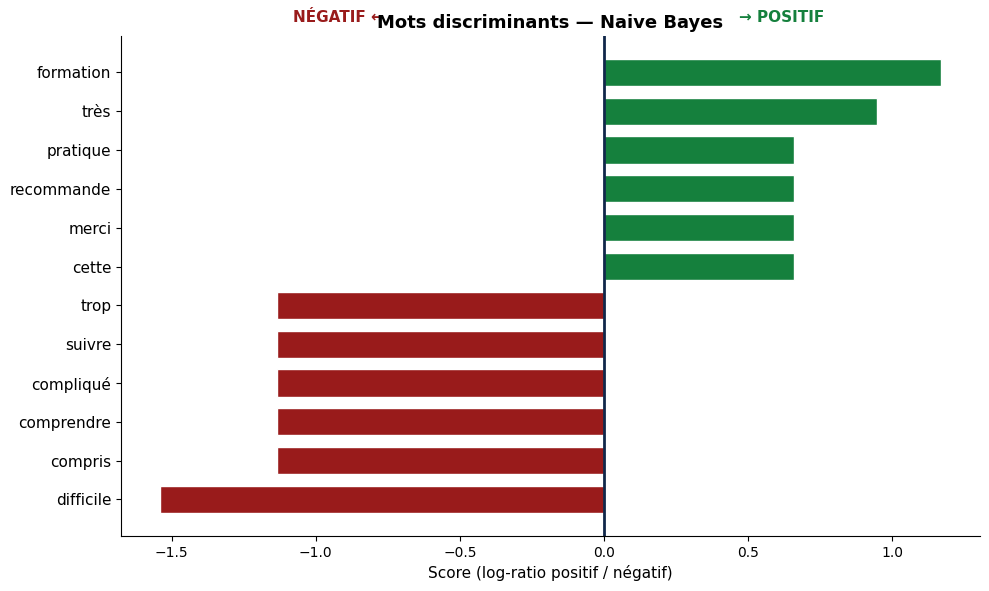

In [104]:
# Visualisation des mots discriminants
fig, ax = plt.subplots(figsize=(10, 6))

mots = [feature_names[i] for i in top_negatif_idx] + [feature_names[i] for i in top_positif_idx[::-1]]
scores = [diff[i] for i in top_negatif_idx] + [diff[i] for i in top_positif_idx[::-1]]
colors = ['#991b1b' if s < 0 else '#15803d' for s in scores]

y_pos = range(len(mots))
ax.barh(y_pos, scores, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(mots, fontsize=11)
ax.axvline(x=0, color='#10274a', linewidth=2)
ax.set_xlabel('Score (log-ratio positif / négatif)', fontsize=11)
ax.set_title('Mots discriminants — Naive Bayes', fontsize=13, fontweight='bold')

ax.text(min(scores)*0.7, len(mots)+0.3, 'NÉGATIF ←', fontsize=11, color='#991b1b', fontweight='bold')
ax.text(max(scores)*0.4, len(mots)+0.3, '→ POSITIF', fontsize=11, color='#15803d', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---

# PARTIE 4 : La probabilité a priori

---

In [105]:
# La probabilité a priori P(classe) influence les prédictions
prior_negatif = np.exp(model.class_log_prior_[0])
prior_positif = np.exp(model.class_log_prior_[1])

print("PROBABILITÉ A PRIORI")
print("=" * 50)
print(f"\n  P(Négatif) = {prior_negatif:.1%}")
print(f"  P(Positif) = {prior_positif:.1%}")

print(f"\n💡 Conséquence :")
print(f"   Comme {prior_positif:.0%} des avis d'entraînement sont positifs,")
print(f"   Naive Bayes 'part avec un avantage' pour la classe positive.")
print(f"   Un avis neutre aura tendance à être classé POSITIF.")

PROBABILITÉ A PRIORI

  P(Négatif) = 28.6%
  P(Positif) = 71.4%

💡 Conséquence :
   Comme 71% des avis d'entraînement sont positifs,
   Naive Bayes 'part avec un avantage' pour la classe positive.
   Un avis neutre aura tendance à être classé POSITIF.


In [106]:
# Testons avec un avis neutre
avis_neutre = ["Le cours était normal"]
X_neutre = vectorizer_bow.transform(avis_neutre)
pred = model.predict(X_neutre)[0]
proba = model.predict_proba(X_neutre)[0]

print(f"Test avec un avis NEUTRE :")
print(f"  \"{avis_neutre[0]}\"")
print(f"  → {'POSITIF' if pred == 1 else 'NÉGATIF'}")
print(f"  → P(négatif) = {proba[0]:.1%} | P(positif) = {proba[1]:.1%}")
print(f"\n💡 Un avis neutre est classé POSITIF à cause de la probabilité a priori.")

Test avec un avis NEUTRE :
  "Le cours était normal"
  → NÉGATIF
  → P(négatif) = 60.0% | P(positif) = 40.0%

💡 Un avis neutre est classé POSITIF à cause de la probabilité a priori.


---

# PARTIE 5 : BoW vs TF-IDF — Comparaison

---

On a vu dans l'Acte II que TF-IDF donne plus de poids aux mots rares. Est-ce que ça aide Naive Bayes ?

In [107]:
# Comparaison BoW vs TF-IDF avec cross-validation
from sklearn.pipeline import Pipeline

# Pipeline BoW + Naive Bayes
pipeline_bow = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB(alpha=1.0))
])

# Pipeline TF-IDF + Naive Bayes
pipeline_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB(alpha=1.0))
])

# Cross-validation (3-fold car petit corpus)
scores_bow = cross_val_score(pipeline_bow, corpus, labels, cv=3, scoring='accuracy')
scores_tfidf = cross_val_score(pipeline_tfidf, corpus, labels, cv=3, scoring='accuracy')

print("COMPARAISON : BoW vs TF-IDF")
print("=" * 50)
print(f"\n  BoW + Naive Bayes :")
print(f"    Accuracy moyenne : {scores_bow.mean():.1%} (+/- {scores_bow.std():.1%})")

print(f"\n  TF-IDF + Naive Bayes :")
print(f"    Accuracy moyenne : {scores_tfidf.mean():.1%} (+/- {scores_tfidf.std():.1%})")

if scores_tfidf.mean() > scores_bow.mean():
    print("\n  💡 TF-IDF améliore légèrement les résultats !")
elif scores_tfidf.mean() < scores_bow.mean():
    print("\n  💡 BoW fonctionne mieux ici (petit corpus).")
else:
    print("\n  💡 Les deux méthodes donnent des résultats similaires.")

print("\n  Sur de gros corpus, TF-IDF prend généralement l'avantage")
print("  car il réduit le poids des mots très fréquents (le, de, est...).")

COMPARAISON : BoW vs TF-IDF

  BoW + Naive Bayes :
    Accuracy moyenne : 84.9% (+/- 11.7%)

  TF-IDF + Naive Bayes :
    Accuracy moyenne : 79.4% (+/- 5.6%)

  💡 BoW fonctionne mieux ici (petit corpus).

  Sur de gros corpus, TF-IDF prend généralement l'avantage
  car il réduit le poids des mots très fréquents (le, de, est...).


---

# PARTIE 6 : Les limites

---

## 6.1 Les négations sont ignorées

Naive Bayes traite chaque mot séparément. "pas bon" contient le mot "bon", qui est un signal **positif** !

In [108]:
# Démonstration : "bon" vs "pas bon"
test_negation = [
    "Ce cours est bon",
    "Ce cours n'est pas bon"
]

X_neg = vectorizer_bow.transform(test_negation)
preds = model.predict(X_neg)
probas = model.predict_proba(X_neg)

print("LIMITE 1 : Les négations sont ignorées")
print("=" * 55)
for avis, pred, proba in zip(test_negation, preds, probas):
    classe = "POSITIF" if pred == 1 else "NÉGATIF"
    print(f"\n  \"{avis}\"")
    print(f"  → {classe} (P(+) = {proba[1]:.1%})")

print("\n  ⚠️ Les deux sont classés pareil !")
print("  Naive Bayes voit 'bon' dans les deux cas,")
print("  il ne comprend pas que 'pas' inverse le sens.")

LIMITE 1 : Les négations sont ignorées

  "Ce cours est bon"
  → POSITIF (P(+) = 58.0%)

  "Ce cours n'est pas bon"
  → POSITIF (P(+) = 58.0%)

  ⚠️ Les deux sont classés pareil !
  Naive Bayes voit 'bon' dans les deux cas,
  il ne comprend pas que 'pas' inverse le sens.


## 6.2 L'ordre des mots est perdu

Comme Bag of Words, Naive Bayes ne tient pas compte de l'ordre :
- "Le formateur aide l'élève" et "L'élève aide le formateur" → même vecteur, même prédiction.

## 6.3 Les mots inconnus sont ignorés

Si un mot n'était pas dans les données d'entraînement, Naive Bayes ne peut pas l'utiliser.

In [109]:
# Mot inconnu
avis_inconnu = ["Ce cours est fantastique"]
X_inconnu = vectorizer_bow.transform(avis_inconnu)

# Comptons les mots reconnus
mots_avis = avis_inconnu[0].lower().split()
mots_connus = [m for m in mots_avis if m in vectorizer_bow.vocabulary_]
mots_ignores = [m for m in mots_avis if m not in vectorizer_bow.vocabulary_]

print("LIMITE 3 : Mots inconnus ignorés")
print("=" * 55)
print(f"\n  Avis : \"{avis_inconnu[0]}\"")
print(f"  Mots reconnus : {mots_connus}")
print(f"  Mots ignorés : {mots_ignores}")
print(f"\n  ⚠️ Le mot 'fantastique' est pourtant très positif,")
print(f"     mais il est absent du vocabulaire d'entraînement.")

LIMITE 3 : Mots inconnus ignorés

  Avis : "Ce cours est fantastique"
  Mots reconnus : ['cours', 'est']
  Mots ignorés : ['ce', 'fantastique']

  ⚠️ Le mot 'fantastique' est pourtant très positif,
     mais il est absent du vocabulaire d'entraînement.


---

# PARTIE 7 : Récapitulatif

---

## Ce qu'on a appris

| Concept | Explication |
|---------|-------------|
| **Naive Bayes** | Un classifieur qui utilise les probabilités pour deviner la classe |
| **Principe** | Compter les mots par classe, calculer les probabilités, choisir la plus haute |
| **Formule** | P(classe\|texte) ∝ P(texte\|classe) × P(classe) |
| **Indépendance** | On suppose que les mots n'influencent pas la présence des autres |
| **Lissage de Laplace** | On ajoute +1 aux comptages pour éviter les probabilités à 0 |
| **Probabilité a priori** | La proportion de chaque classe influence les prédictions |

## Forces et limites

| ✅ Forces | ❌ Limites |
|-----------|------------|
| Rapide à entraîner | Ignore l'ordre des mots |
| Fonctionne avec peu de données | Ne comprend pas les négations |
| Donne des probabilités (confiance) | Mots inconnus ignorés |
| Facile à interpréter | L'hypothèse naïve est parfois trop simpliste |
| Baseline solide pour la classification | Sensible au déséquilibre des classes |

## Progression de la série

| Acte | Technique | Ce qu'on apprend |
|------|-----------|------------------|
| I | Bag of Words | Transformer texte → vecteur |
| II | TF-IDF | Pondérer les mots importants |
| **III** | **Naive Bayes** | **Classifier avec les probabilités** |
| IV | N-grammes | Capturer l'ordre des mots |

## Et ensuite ?

Naive Bayes fonctionne bien, mais il ne voit pas la différence entre "pas bon" et "bon" !

L'Acte IV introduira les **N-grammes**, qui capturent les séquences de mots ("pas bon" comme un seul bloc) pour mieux comprendre le contexte.